Portfolio Project One: Code

By: Elena Arroyo

In [220]:
#importing libraries
import pandas as pd
from dotenv import load_dotenv
import os
import requests
import matplotlib.pyplot as plt


In [221]:
load_dotenv()
api_key = os.getenv("CENSUS_API_KEY")
#Educational attainment for Black women over the age of 25 (bachelor's degree and above)
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,C15002B_011E&for=county:*&in=state:37&key={api_key}"
response = requests.get(url)
response

<Response [200]>

In [222]:
#Black women in each county with a Bachelor's or higher
variables = ",".join([
    "NAME",
    "C15002B_011E"
])
url = f"https://api.census.gov/data/2024/acs/acs1?get={variables}&for=county:*&in=state:37&key={api_key}"
reponse = requests.get(url)
data= response.json()
df = pd.DataFrame(data[1:],columns=data[0])
df.head()
df.to_csv("BWEduAttain.csv",index=False)
BW_Edu = pd.read_csv("BWEduAttain.csv")



In [225]:
#Total population of Black women in each county
variables2 = ",".join([
    "NAME",
    "B01001B_017E"
])
url2 = f"https://api.census.gov/data/2024/acs/acs1?get={variables2}&for=county:*&in=state:37&key={api_key}"
response2 = requests.get(url2)
data2 = response2.json()
df2 = pd.DataFrame(data2[1:],columns=data2[0])
df2.head()
df2.to_csv("BWPop.csv",index=False)
BW_Pop = pd.read_csv("BWPop.csv")

In [224]:
#Total population of people in each county
variables3 = ",".join([
    "NAME",
    "B01001_001E"
])
url3 = f"https://api.census.gov/data/2024/acs/acs1?get={variables3}&for=county:*&in=state:37&key={api_key}"
response3 = requests.get(url3)
data3 = response3.json()
df3 = pd.DataFrame(data3[1:],columns=data3[0])
df3.head()
df3.to_csv("TotalPop.csv",index=False)
TotPop = pd.read_csv("TotalPop.csv")


In [226]:
#Cleaning the data and dropping the nulll/missing values from the datasets
clean_BWE = BW_Edu.dropna()
clean_BWPop = BW_Pop.dropna()
cleanTotPop = TotPop.dropna()

Text(0, 0.5, "Black women with a Bachelor's degree or higher")

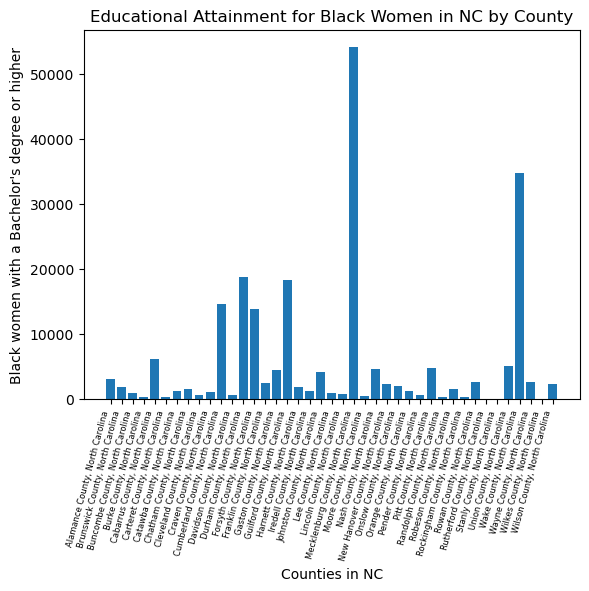

In [227]:
#Histogram for Educational Attainment for Black Women in NC by County
plt.bar(clean_BWE["NAME"],clean_BWE["C15002B_011E"])
plt.xticks(rotation=75,fontsize = 6,ha='right')
plt.title("Educational Attainment for Black Women in NC by County")
plt.xlabel("Counties in NC")
plt.ylabel("Black women with a Bachelor's degree or higher")

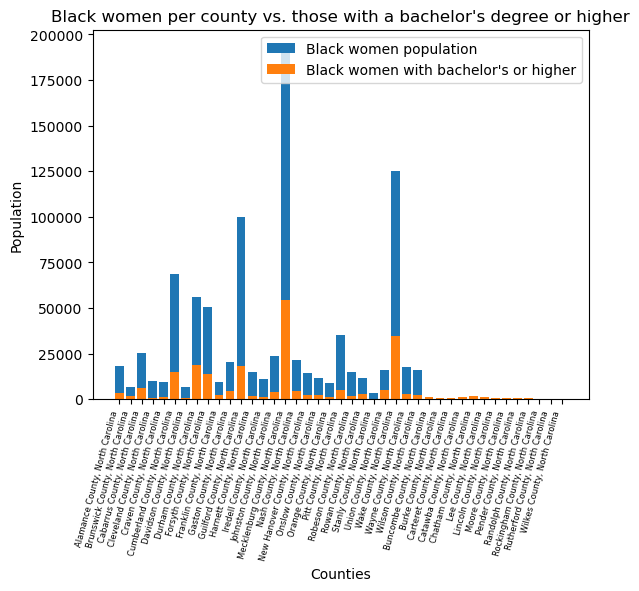

In [228]:
#Black women per county vs. those with a bachelor's degree or higher
plt.bar(clean_BWPop["NAME"],clean_BWPop["B01001B_017E"],label = "Black women population")
plt.bar(clean_BWE["NAME"],clean_BWE["C15002B_011E"], label= "Black women with bachelor's or higher")
plt.xticks(rotation=75,fontsize = 6,ha='right')
plt.xlabel("Counties")
plt.ylabel("Population")
plt.title("Black women per county vs. those with a bachelor's degree or higher")
plt.legend()


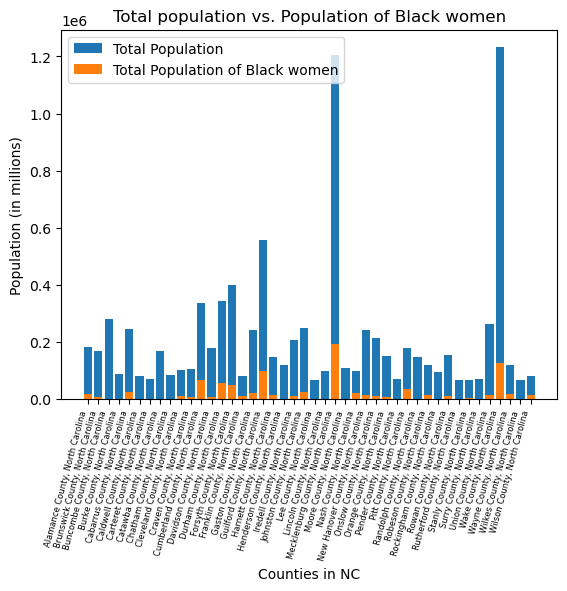

In [229]:
#Total population versus total population of black women per county
plt.bar(cleanTotPop["NAME"],cleanTotPop["B01001_001E"],label ="Total Population")
plt.bar(clean_BWPop["NAME"], clean_BWPop["B01001B_017E"],label="Total Population of Black women")
plt.xticks(rotation=75,fontsize = 6,ha='right')
plt.xlabel("Counties in NC")
plt.ylabel("Population (in millions)")
plt.title("Total population vs. Population of Black women")
plt.legend()